# Lab | EDA Bivariate Analysis

## Step 0 — Imports + Load Dataset

In [1]:
# Step 0 - Import libraries
# pandas: table/data handling
# numpy: numeric operations
# matplotlib/seaborn: plots
# scipy: statistical tests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
import scipy.stats as stats
import statsmodels as sm

# Step 0 - Load dataset
# pd.read_csv() reads a CSV file into a DataFrame
# Replace the filename with your real file name if needed
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

# Step 0 - Quick check: show first rows
df.head()


,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


# Part 1 — Best-Seller vs Category
## Step 1 — Check needed columns exist

In [2]:
# Step 1 - Check columns
# df.columns shows all column names
df.columns


Index(['uid', 'asin', 'title', 'stars', 'reviews', 'price', 'isBestSeller',
       'boughtInLastMonth', 'category'],
      dtype='object')

In [3]:
# Step 1.1 - OPTIONAL: rename columns to expected names
# rename() changes column names
df = df.rename(columns={
    "Category": "category",
    "is_best_seller": "isBestSeller"
})


## Step 2 — Crosstab (category x isBestSeller)

In [4]:
# Step 2 - Create crosstab table
# pd.crosstab counts occurrences between two columns
ct = pd.crosstab(df["category"], df["isBestSeller"])
ct.head()


isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3


## Step 3 — Best-seller proportion per category (sorted)

In [5]:
# Step 3 - Compute proportion of best-sellers per category
# We divide best-seller count by total count in that category
# .sum(axis=1) sums across columns (row total)

best_seller_rate = (ct[True] / ct.sum(axis=1)).sort_values(ascending=False)

# Step 3 - View top categories with highest best-seller rate
best_seller_rate.head(10)


category
Grocery                           0.058135
Smart Home Security & Lighting    0.057692
Health & Personal Care            0.057686
Mobile Phone Accessories          0.042471
Power & Hand Tools                0.035339
Billiard, Snooker & Pool          0.032129
Pet Supplies                      0.030200
Home Brewing & Wine Making        0.028455
Wind Instruments                  0.028000
Mirrors                           0.028000
dtype: float64

## Step 4 — Chi-square test (independence)

In [6]:
# Step 4 - Chi-square test
# chi2_contingency() tests if category and best-seller are independent
chi2, p, dof, expected = chi2_contingency(ct)

chi2, p


(np.float64(36540.20270061387), np.float64(0.0))

## Step 5 — Cramér’s V (strength of association)

In [7]:
# Step 5 - Compute Cramér's V
# This tells strength of association (0 to 1)

n = ct.values.sum()
phi2 = chi2 / n
r, k = ct.shape

cramers_v = np.sqrt(phi2 / (min(r-1, k-1)))
cramers_v


np.float64(0.1222829439760564)

## Step 6 — Stacked bar chart (category vs best-seller)

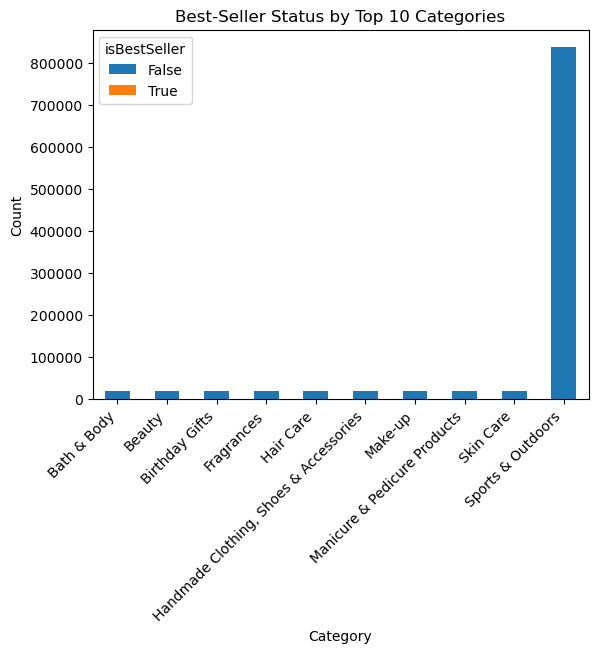

In [8]:
# Step 6 - Stacked bar chart for top categories by volume (for readability)
# We'll keep top 10 categories by count

top10_categories = df["category"].value_counts().head(10).index
ct_top10 = pd.crosstab(df[df["category"].isin(top10_categories)]["category"],
                       df[df["category"].isin(top10_categories)]["isBestSeller"])

# plot kind="bar" makes bar chart
ct_top10.plot(kind="bar", stacked=True)

plt.title("Best-Seller Status by Top 10 Categories")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()


# Part 2 — Prices & Ratings Across Categories (Remove Outliers first)
## Step 7 — Ensure price and stars/rating are numeric

In [9]:
# Step 7 - Check dtypes
df[["price", "stars"]].dtypes


price    float64
stars    float64
dtype: object

In [10]:
# Step 7.1 - Convert price to numeric (safe conversion)
# errors='coerce' turns bad values into NaN
df["price"] = pd.to_numeric(df["price"], errors="coerce")

# Step 7.2 - Convert stars/rating to numeric
df["stars"] = pd.to_numeric(df["stars"], errors="coerce")

# Step 7.3 - Drop rows where price or stars is missing (needed for analysis)
df = df.dropna(subset=["price", "stars"])


## Step 8 — Remove price outliers using IQR

In [11]:
# Step 8 - Remove outliers using IQR
# Q1 = 25th percentile, Q3 = 75th percentile
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter dataframe to keep only non-outliers
df_no_outliers = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)]

df.shape, df_no_outliers.shape


((2443651, 9), (2115963, 9))

## Step 9 — Violin plot: price vs category (top 20 categories)

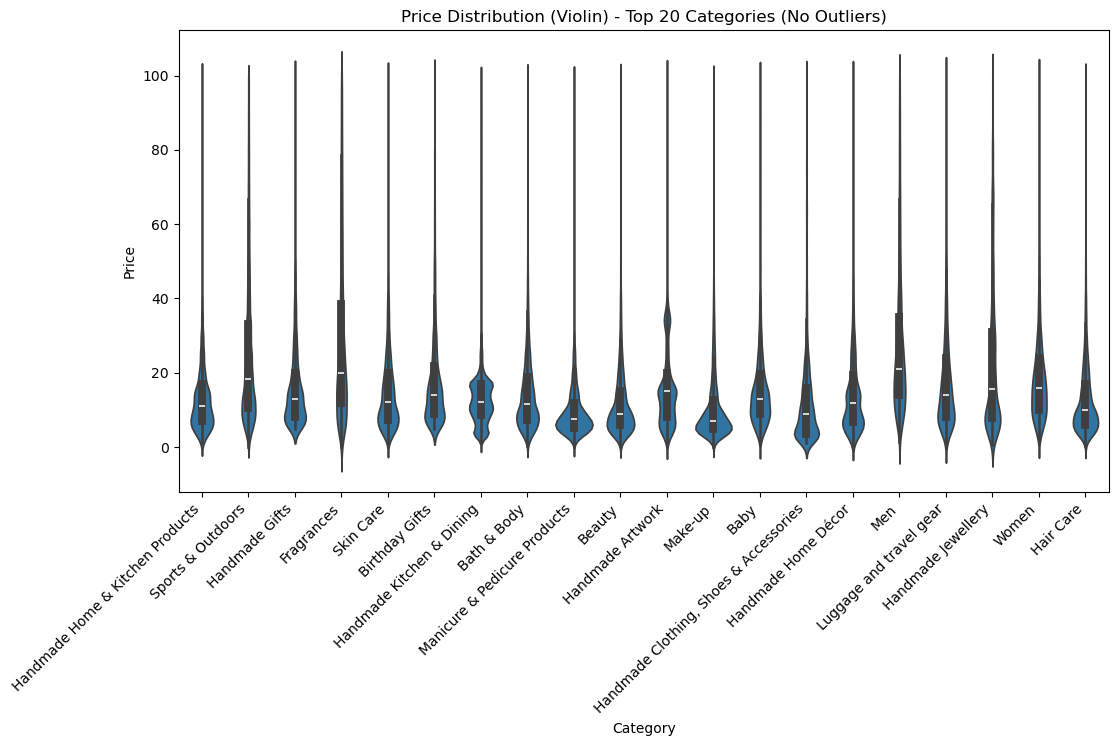

In [12]:
# Step 9 - Choose top 20 categories by count for readability
top20_categories = df_no_outliers["category"].value_counts().head(20).index
df_top20 = df_no_outliers[df_no_outliers["category"].isin(top20_categories)]

plt.figure(figsize=(12, 6))
sns.violinplot(data=df_top20, x="category", y="price")

plt.title("Price Distribution (Violin) - Top 20 Categories (No Outliers)")
plt.xlabel("Category")
plt.ylabel("Price")
plt.xticks(rotation=45, ha="right")
plt.show()


## Step 10 — Which category has highest median price (ALL categories, no filter)

In [13]:
# Step 10 - Median price per category (no filter)
median_price_by_cat = df_no_outliers.groupby("category")["price"].median().sort_values(ascending=False)

median_price_by_cat.head(10)


category
Desktop PCs               74.00
Boxing Shoes              69.79
Tablets                   69.00
Graphics Cards            68.54
Motherboards              67.92
Made in Italy Handmade    64.00
Digital Frames            63.90
Streaming Clients         62.68
Golf Shoes                62.39
Ski Helmets               61.33
Name: price, dtype: float64

## Step 11 — Bar chart: average price (top 10 categories by count)

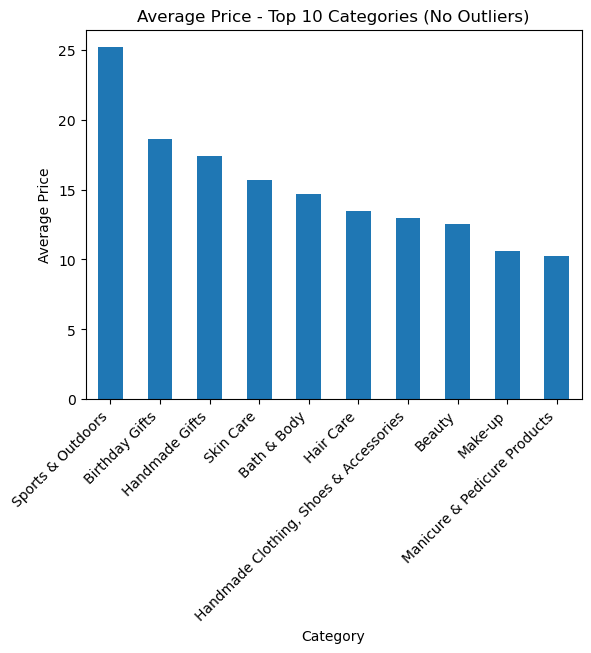

In [14]:
# Step 11 - Top 10 categories by count
top10_categories = df_no_outliers["category"].value_counts().head(10).index

# Average price per category
avg_price_top10 = df_no_outliers[df_no_outliers["category"].isin(top10_categories)] \
    .groupby("category")["price"].mean().sort_values(ascending=False)

avg_price_top10.plot(kind="bar")

plt.title("Average Price - Top 10 Categories (No Outliers)")
plt.xlabel("Category")
plt.ylabel("Average Price")
plt.xticks(rotation=45, ha="right")
plt.show()


## Step 12 — Box plot: stars vs category (top 10 categories)

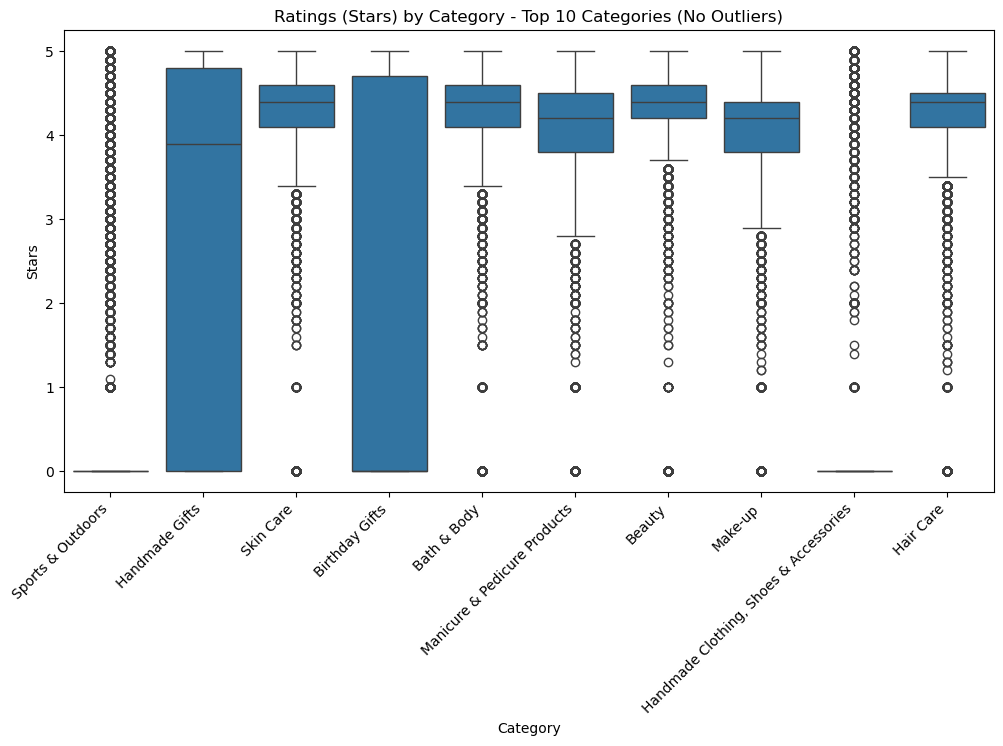

In [15]:
# Step 12 - Box plot for ratings (stars) by category for top 10 categories by count
top10_categories = df_no_outliers["category"].value_counts().head(10).index
df_top10 = df_no_outliers[df_no_outliers["category"].isin(top10_categories)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top10, x="category", y="stars")

plt.title("Ratings (Stars) by Category - Top 10 Categories (No Outliers)")
plt.xlabel("Category")
plt.ylabel("Stars")
plt.xticks(rotation=45, ha="right")
plt.show()


## Step 13 — Which category has highest median rating (ALL categories)

In [16]:
# Step 13 - Median stars per category (no filter)
median_rating_by_cat = df_no_outliers.groupby("category")["stars"].median().sort_values(ascending=False)

median_rating_by_cat.head(10)


category
Computer Memory                 4.7
Building & Construction Toys    4.6
Office Paper Products           4.6
Luxury Food & Drink             4.6
Kids' Play Figures              4.6
Hobbies                         4.6
Beer, Wine & Spirits            4.6
Laptop Accessories              4.6
Cables & Accessories            4.5
CPUs                            4.5
Name: stars, dtype: float64

# Part 3 — Price vs Rating Relationship
## Step 14 — Correlation coefficient (price vs stars)

In [17]:
# Step 14 - Correlation between price and stars
# corr() returns Pearson correlation by default
corr_price_stars = df_no_outliers["price"].corr(df_no_outliers["stars"])
corr_price_stars


np.float64(-0.07767299878178476)

## Step 15 — Scatter plot (price vs stars)

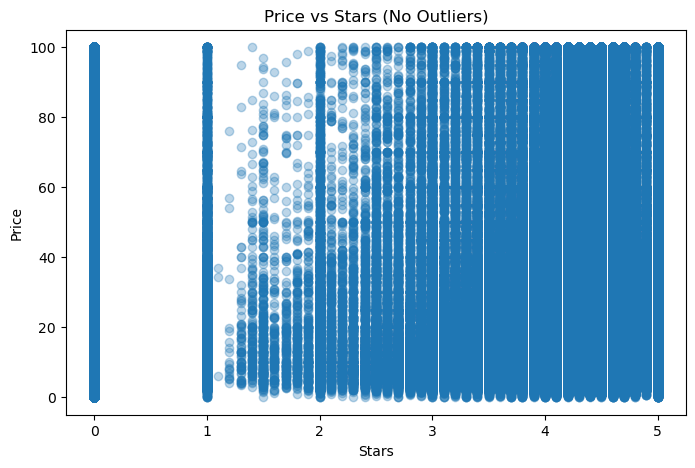

In [18]:
# Step 15 - Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df_no_outliers["stars"], df_no_outliers["price"], alpha=0.3)

plt.title("Price vs Stars (No Outliers)")
plt.xlabel("Stars")
plt.ylabel("Price")
plt.show()


## Step 16 — Correlation heatmap for numeric columns

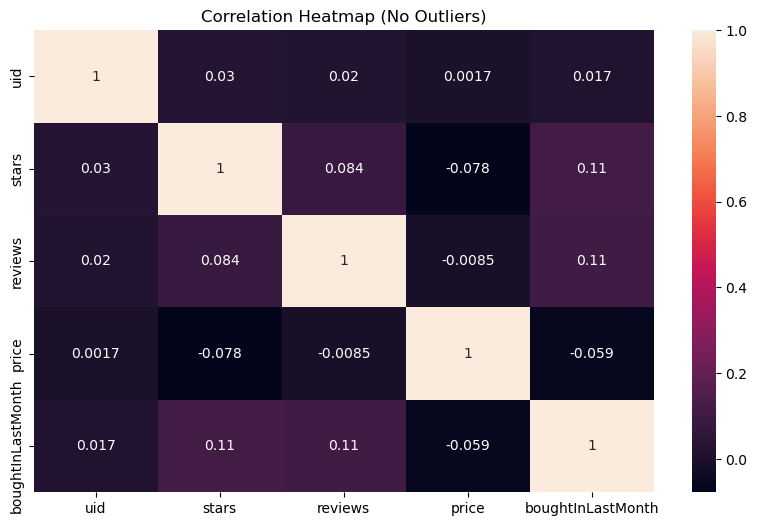

In [19]:
# Step 16 - Heatmap of correlations between numeric columns
# select_dtypes finds numeric columns
numeric_df = df_no_outliers.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Heatmap (No Outliers)")
plt.show()


## Step 17 — QQ Plot for price normality

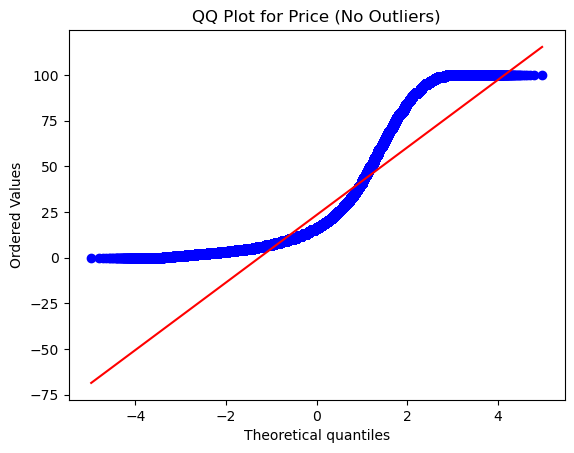

In [20]:
# Step 17 - QQ Plot for price (check normal distribution)
# stats.probplot() generates QQ-plot data
# dist="norm" compares against a normal distribution
stats.probplot(df_no_outliers["price"], dist="norm", plot=plt)

# title() adds a title
plt.title("QQ Plot for Price (No Outliers)")

# show() displays the plot
plt.show()



## Bonus — Repeat correlation without removing outliers

In [21]:
# Bonus - Correlation with outliers included
corr_with_outliers = df["price"].corr(df["stars"])
corr_with_outliers


np.float64(-0.12490673262159065)